# Transforming Data into Features — Solution Notebook (Complete + Extended)

**Audience:** Data scientist preparing clothing-review data for downstream ML models (classification of recommendation, rating prediction, etc.).

This notebook contains:
- Complete solutions for every step
- Alternate coding approaches that achieve the same result
- Extra practice transformations
- A simulation section where parameters can be changed
- Visualizations of before/after scaling

## Analysis Flowchart
```mermaid
flowchart TD
    A[Load reviews.csv] --> B[Explore columns & dtypes]
    B --> C[Binary encode recommended<br/>True→1 False→0]
    C --> D[Ordinal encode rating<br/>Loved it→5 ... Hated it→1]
    D --> E[One-hot encode department_name]
    E --> F[Convert review_date to datetime]
    F --> G[Select numerical features]
    G --> H[Set clothing_id as index]
    H --> I[StandardScaler fit_transform]
    I --> J[More practice: division one-hot,<br/>date parts, age bins]
    J --> K[Simulation: change dicts / scaler / subset]
    K --> L[Compare scaled distributions & insights]
```


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
%matplotlib inline


## Basic Exploration

### 1. Import the dataset

In [2]:
reviews = pd.read_csv("reviews.csv")
print("Shape:", reviews.shape)
reviews.head(3)


Shape: (5000, 9)


,clothing_id,age,review_title,review_text,recommended,division_name,department_name,review_date,rating
0,1095,39,"Cute,looks like a dress on",If you are afraid of the jumpsuit trend but li...,True,General,Dresses,2019-07-08,Liked it
1,1095,28,"So cute, great print!",I love fitted top dresses like this but i find...,True,General,Dresses,2019-05-17,Loved it
2,699,37,So flattering!,"I love these cozy, fashionable leggings. they ...",True,Initmates,Intimate,2019-06-24,Loved it


### 2. Column names and data types

In [3]:
print("Column names:")
print(reviews.columns.tolist())
print("\n--- .info() ---")
reviews.info()


Column names:
['clothing_id', 'age', 'review_title', 'review_text', 'recommended', 'division_name', 'department_name', 'review_date', 'rating']

--- .info() ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   clothing_id      5000 non-null   int64
 1   age              5000 non-null   int64
 2   review_title     4174 non-null   str  
 3   review_text      4804 non-null   str  
 4   recommended      5000 non-null   bool 
 5   division_name    4996 non-null   str  
 6   department_name  4996 non-null   str  
 7   review_date      5000 non-null   str  
 8   rating           5000 non-null   str  
dtypes: bool(1), int64(2), str(6)
memory usage: 317.5 KB


## Data Transformations

### 3. Inspect recommended

In [4]:
print(reviews["recommended"].value_counts(dropna=False))
print("\nDtype:", reviews["recommended"].dtype)


recommended
True     4166
False     834
Name: count, dtype: int64

Dtype: bool


### 4–5. Binary transform of recommended

**Primary approach:** dictionary + map  
**Alternate 1:** `.astype(int)` because the column is already boolean  
**Alternate 2:** `.replace({True: 1, False: 0})`

In [5]:
# Primary: dictionary
binary_dict = {True: 1, False: 0}
reviews["recommended"] = reviews["recommended"].map(binary_dict)

print("After map / dictionary transform:")
print(reviews["recommended"].value_counts())

# --- Alternate approaches (already applied above, shown for learning) ---
# reviews["recommended"] = reviews["recommended"].astype(int)
# reviews["recommended"] = reviews["recommended"].replace({True: 1, False: 0})


After map / dictionary transform:
recommended
1    4166
0     834
Name: count, dtype: int64


### 6. Inspect rating

In [6]:
print(reviews["rating"].value_counts(dropna=False))


rating
Loved it     2798
Liked it     1141
Was okay      564
Not great     304
Hated it      193
Name: count, dtype: int64


### 7–8. Ordinal transform of rating

**Primary:** dictionary + map  
**Alternate:** `.replace(rating_dict)`

In [7]:
rating_dict = {
    "Loved it": 5,
    "Liked it": 4,
    "Was okay": 3,
    "Not great": 2,
    "Hated it": 1
}

reviews["rating"] = reviews["rating"].map(rating_dict)
# Alternate: reviews["rating"] = reviews["rating"].replace(rating_dict)

print("After ordinal encoding:")
print(reviews["rating"].value_counts().sort_index(ascending=False))


After ordinal encoding:
rating
5    2798
4    1141
3     564
2     304
1     193
Name: count, dtype: int64


### 9–11. One-hot encode department_name

Note: there are 4 missing values; `pd.get_dummies` by default does **not** create a column for NaN.

In [8]:
print("Value counts (including NaN):")
print(reviews["department_name"].value_counts(dropna=False))

one_hot = pd.get_dummies(reviews["department_name"], prefix="dept")
# Alternate with drop_first to avoid multicollinearity:
# one_hot = pd.get_dummies(reviews["department_name"], prefix="dept", drop_first=True)

print("\nOne-hot shape:", one_hot.shape)
print(one_hot.head(2))

# Join back
reviews = reviews.join(one_hot)
# Alternate: reviews = pd.concat([reviews, one_hot], axis=1)

print("\nColumns after join:")
print(reviews.columns.tolist())


Value counts (including NaN):
department_name
Tops        2196
Dresses     1322
Bottoms      848
Intimate     378
Jackets      224
Trend         28
NaN            4
Name: count, dtype: int64

One-hot shape: (5000, 6)
   dept_Bottoms  dept_Dresses  dept_Intimate  dept_Jackets  dept_Tops  dept_Trend
0         False          True          False         False      False       False
1         False          True          False         False      False       False

Columns after join:
['clothing_id', 'age', 'review_title', 'review_text', 'recommended', 'division_name', 'department_name', 'review_date', 'rating', 'dept_Bottoms', 'dept_Dresses', 'dept_Intimate', 'dept_Jackets', 'dept_Tops', 'dept_Trend']


### 12. Convert review_date to datetime

In [9]:
reviews["review_date"] = pd.to_datetime(reviews["review_date"])
# Alternate with explicit format: pd.to_datetime(reviews["review_date"], format="%Y-%m-%d")

print("Dtype after conversion:", reviews["review_date"].dtype)
print(reviews["review_date"].head())


Dtype after conversion: datetime64[us]
0   2019-07-08
1   2019-05-17
2   2019-06-24
3   2019-12-06
4   2019-10-04
Name: review_date, dtype: datetime64[us]


## Scaling the Data

### 13–14. Select numerical features & set index

In [10]:
# Numerical columns we created / need
num_cols = ["clothing_id", "age", "recommended", "rating"] + [c for c in reviews.columns if c.startswith("dept_")]
print("Numerical columns selected:")
print(num_cols)

reviews_num = reviews[num_cols].copy()
reviews_num = reviews_num.set_index("clothing_id")
print("\nShape of reviews_num:", reviews_num.shape)
print(reviews_num.head(3))


Numerical columns selected:
['clothing_id', 'age', 'recommended', 'rating', 'dept_Bottoms', 'dept_Dresses', 'dept_Intimate', 'dept_Jackets', 'dept_Tops', 'dept_Trend']

Shape of reviews_num: (5000, 9)
             age  recommended  rating  dept_Bottoms  dept_Dresses  dept_Intimate  dept_Jackets  dept_Tops  dept_Trend
clothing_id                                                                                                          
1095          39            1       4         False          True          False         False      False       False
1095          28            1       5         False          True          False         False      False       False
699           37            1       5         False         False           True         False      False       False


### 15. StandardScaler

In [11]:
scaler = StandardScaler()
scaled = scaler.fit_transform(reviews_num)

print("Scaled array shape:", scaled.shape)
print("\nFirst 5 rows of scaled data:")
print(np.round(scaled[:5], 3))

# Also useful: look at the scaling parameters
print("\nFeature means used by scaler:", np.round(scaler.mean_, 3))
print("Feature scales (std):", np.round(scaler.scale_, 3))


Scaled array shape: (5000, 9)

First 5 rows of scaled data:
[[-0.348  0.447 -0.19  -0.452  1.668 -0.286 -0.217 -0.885 -0.075]
 [-1.245  0.447  0.716 -0.452  1.668 -0.286 -0.217 -0.885 -0.075]
 [-0.511  0.447  0.716 -0.452 -0.6    3.497 -0.217 -0.885 -0.075]
 [-0.593  0.447  0.716 -0.452  1.668 -0.286 -0.217 -0.885 -0.075]
 [-0.919  0.447  0.716 -0.452  1.668 -0.286 -0.217 -0.885 -0.075]]

Feature means used by scaler: [4.3271e+01 8.3300e-01 4.2090e+00 1.7000e-01 2.6400e-01 7.6000e-02
 4.5000e-02 4.3900e-01 6.0000e-03]
Feature scales (std): [12.268  0.373  1.104  0.375  0.441  0.264  0.207  0.496  0.075]


### Quick visual: distribution before vs after scaling (age & rating)

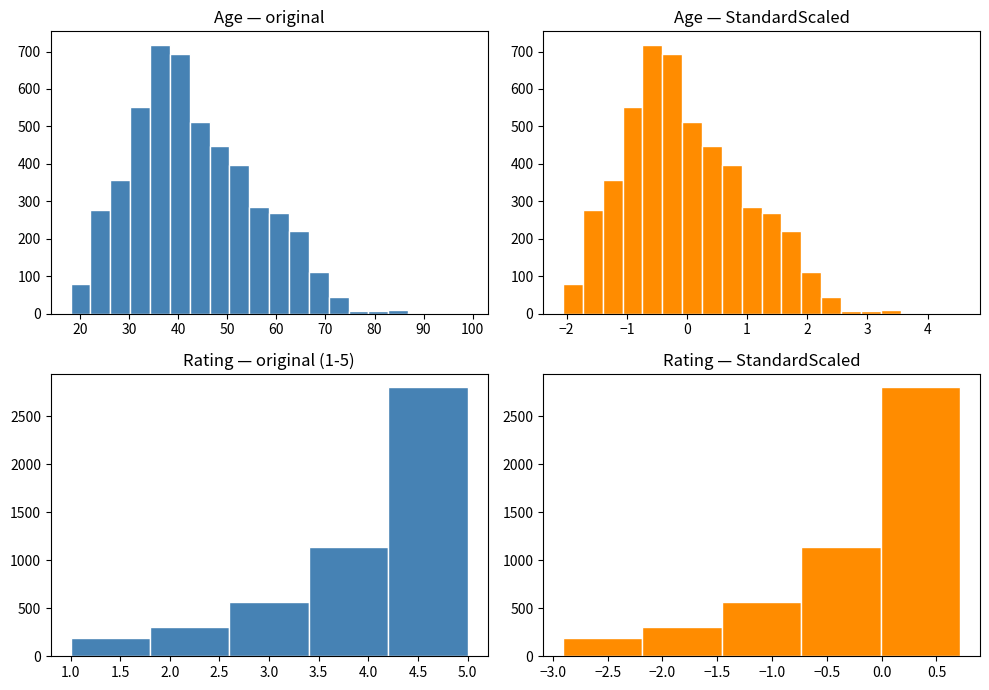

Saved figure: reviews_scaling_comparison.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].hist(reviews_num["age"], bins=20, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Age — original")
axes[0, 1].hist(scaled[:, 0], bins=20, color="darkorange", edgecolor="white")
axes[0, 1].set_title("Age — StandardScaled")

axes[1, 0].hist(reviews_num["rating"], bins=5, color="steelblue", edgecolor="white")
axes[1, 0].set_title("Rating — original (1-5)")
axes[1, 1].hist(scaled[:, 2], bins=5, color="darkorange", edgecolor="white")
axes[1, 1].set_title("Rating — StandardScaled")

plt.tight_layout()
plt.savefig("reviews_scaling_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved figure: reviews_scaling_comparison.png")


## More Practice — Extra Transformations

### A. One-hot encode division_name as well

In [13]:
print(reviews["division_name"].value_counts(dropna=False))

# Fill the 4 NaNs so they become a real category (optional but cleaner)
reviews["division_name"] = reviews["division_name"].fillna("Unknown")
div_one_hot = pd.get_dummies(reviews["division_name"], prefix="div")
reviews = reviews.join(div_one_hot)
print("New division columns:", [c for c in reviews.columns if c.startswith("div_")])


division_name
General           2884
General Petite    1787
Initmates          325
NaN                  4
Name: count, dtype: int64
New division columns: ['div_General', 'div_General Petite', 'div_Initmates', 'div_Unknown']


### B. Extract year / month / day-of-week from review_date

In [14]:
reviews["review_year"] = reviews["review_date"].dt.year
reviews["review_month"] = reviews["review_date"].dt.month
reviews["review_dow"] = reviews["review_date"].dt.dayofweek  # 0=Mon

print(reviews[["review_date", "review_year", "review_month", "review_dow"]].head())
print("\nYear value counts:")
print(reviews["review_year"].value_counts().sort_index())


  review_date  review_year  review_month  review_dow
0  2019-07-08         2019             7           0
1  2019-05-17         2019             5           4
2  2019-06-24         2019             6           0
3  2019-12-06         2019            12           4
4  2019-10-04         2019            10           4

Year value counts:
review_year
2019    5000
Name: count, dtype: int64


### C. Age bins + one-hot

In [15]:
bins = [0, 30, 50, 100]
labels = ["young", "mid", "senior"]
reviews["age_bin"] = pd.cut(reviews["age"], bins=bins, labels=labels)
age_dummies = pd.get_dummies(reviews["age_bin"], prefix="age")
reviews = reviews.join(age_dummies)
print(reviews[["age", "age_bin"]].head(8))
print("\nAge-bin counts:\n", reviews["age_bin"].value_counts())


   age age_bin
0   39     mid
1   28   young
2   37     mid
3   36     mid
4   32     mid
5   51  senior
6   39     mid
7   46     mid

Age-bin counts:
 age_bin
mid       2925
senior    1361
young      714
Name: count, dtype: int64


### D. Alternate scaler — MinMaxScaler comparison

In [16]:
# Rebuild a clean numeric matrix including a couple of new features
extra_num = ["age", "recommended", "rating", "review_month"] + \
            [c for c in reviews.columns if c.startswith("dept_")]
X = reviews[extra_num].copy()

std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

X_std = std_scaler.fit_transform(X)
X_mm = minmax_scaler.fit_transform(X)

print("StandardScaler  → mean≈0, std≈1")
print("  means:", np.round(X_std.mean(axis=0)[:4], 4))
print("  stds :", np.round(X_std.std(axis=0)[:4], 4))

print("\nMinMaxScaler   → values in [0, 1]")
print("  mins :", np.round(X_mm.min(axis=0)[:4], 4))
print("  maxs :", np.round(X_mm.max(axis=0)[:4], 4))


StandardScaler  → mean≈0, std≈1
  means: [-0. -0.  0.  0.]
  stds : [1. 1. 1. 1.]

MinMaxScaler   → values in [0, 1]
  mins : [0. 0. 0. 0.]
  maxs : [1. 1. 1. 1.]


## Simulation Section

Change parameters and observe how the scaled results move.


In [17]:
# ----- Simulation 1: invert the rating scale -----
rating_dict_inv = {
    "Loved it": 1,
    "Liked it": 2,
    "Was okay": 3,
    "Not great": 4,
    "Hated it": 5
}
# (We already overwrote the column; reload a fresh copy for fair comparison)
raw = pd.read_csv("reviews.csv")
sim_rating = raw["rating"].map(rating_dict_inv)
print("Inverted rating value counts:")
print(sim_rating.value_counts().sort_index())

# ----- Simulation 2: scale only the Dresses subset -----
dresses_mask = raw["department_name"] == "Dresses"
dresses_age = raw.loc[dresses_mask, "age"].values.reshape(-1, 1)
scaler_d = StandardScaler()
scaled_dresses_age = scaler_d.fit_transform(dresses_age)
print(f"\nDresses only — age mean after scaling: {scaled_dresses_age.mean():.4f}")
print(f"Dresses only — age std  after scaling: {scaled_dresses_age.std():.4f}")
print(f"(Original dresses age mean was {dresses_age.mean():.1f})")

# ----- Simulation 3: StandardScaler with_mean=False -----
scaler_no_center = StandardScaler(with_mean=False)
scaled_no_center = scaler_no_center.fit_transform(reviews_num[["age", "rating"]])
print("\nwith_mean=False (age, rating) first 3 rows:")
print(np.round(scaled_no_center[:3], 3))
print("Means of scaled columns (should NOT be ~0):", np.round(scaled_no_center.mean(axis=0), 3))


Inverted rating value counts:
rating
1    2798
2    1141
3     564
4     304
5     193
Name: count, dtype: int64

Dresses only — age mean after scaling: -0.0000
Dresses only — age std  after scaling: 1.0000
(Original dresses age mean was 41.9)

with_mean=False (age, rating) first 3 rows:
[[3.179 3.623]
 [2.282 4.528]
 [3.016 4.528]]
Means of scaled columns (should NOT be ~0): [3.527 3.812]


### Simulation visual — effect of different scalers on age

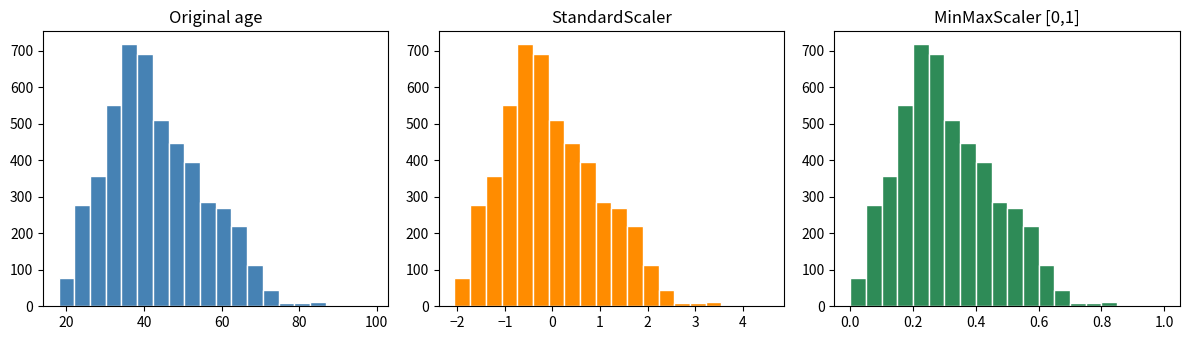

In [18]:
age_vals = reviews_num["age"].values.reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].hist(age_vals, bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Original age")

axes[1].hist(StandardScaler().fit_transform(age_vals), bins=20, color="darkorange", edgecolor="white")
axes[1].set_title("StandardScaler")

axes[2].hist(MinMaxScaler().fit_transform(age_vals), bins=20, color="seagreen", edgecolor="white")
axes[2].set_title("MinMaxScaler [0,1]")

plt.tight_layout()
plt.savefig("reviews_scaler_simulation.png", dpi=120, bbox_inches="tight")
plt.show()


## Key Insights from the Transformations

1. **Binary encoding** of `recommended` turns a Boolean into a numeric feature usable by any model.
2. **Ordinal encoding** of `rating` preserves the natural order (Loved > Liked > … > Hated).
3. **One-hot encoding** of `department_name` expands a single categorical column into several binary indicators; remember the NaN rows produce all-zeros.
4. **Datetime conversion** unlocks rich derived features (month, day-of-week, seasonality).
5. **StandardScaler** centers features at 0 with unit variance — essential when features have very different ranges (age vs. binary flags vs. rating).
6. Always inspect `.value_counts()` and dtypes before and after each transform; small data-quality issues (4 missing departments) become visible early.


## End of Solution Notebook
You now have a fully numeric, scaled feature matrix ready for modeling. Experiment further by adding text features (TF-IDF of review_text) or building a simple classifier that predicts `recommended`.
